In [1]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from deepthinking.models import dt_net_recall_2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load('./outputs/mazes_ablation/training-rusty-Tayla/model_best.pth', map_location=device)

state_dict = checkpoint['net']

/tmp/ipykernel_409060/2053517538.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('./outputs/mazes_ablation/training-rusty-Tayla/model_best.pth', 

In [3]:
model = dt_net_recall_2d(width=128, in_channels=3)

# --- FIX: Strip the "module." prefix ---
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k # remove `module.`
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
model.to(device)
model.eval()

DTNet(
  (projection): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU()
  )
  (recur_block): Sequential(
    (0): Conv2d(131, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Sequential(
      (0): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
      (1): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(128, 32, kernel_size=(3, 3), stride=(1,

In [1]:
from easy_to_hard_data import MazeDataset
testset = MazeDataset("data", train=False, size=9, download=False)

Loading mazes of size 9 x 9.


In [5]:
x = testset[0][0].unsqueeze(0).permute(0,3,1,2).to(device)
a_5 = torch.relu(model.projection(x)).to(device)
max_iters = 100
snapshot_every = 1   # save every 5 iterations

# Containers to store snapshots
snapshots = []  # list of dicts { 'iter': it, 'a1':..., 'a2':..., 'a3':..., 'a4':..., 'a5':... }

for it in range(max_iters):
    a_1 = model.recur_block[0](torch.cat([a_5, x], dim=1)).to(device)
    conv_a1 = model.recur_block[1][0].conv1(a_1).to(device)
    a_21 = torch.relu(conv_a1).to(device)
    conv_a21 = model.recur_block[1][0].conv2(a_21).to(device)
    a_3 = torch.relu(conv_a21 + a_1).to(device)
    conv_a3 = model.recur_block[1][1].conv1(a_3).to(device)
    a_41 = torch.relu(conv_a3).to(device)
    conv_a41 = model.recur_block[1][1].conv2(a_41).to(device)
    a_5 = torch.relu(conv_a41 + a_3).to(device)

    # Save snapshot every snapshot_every iterations (including iteration 0 if desired)
    if (it % snapshot_every) == 0:
        # detach and move to cpu numpy, take first batch element [0]
        snap = {
            'iter': it,
            'a1': a_1.detach().cpu().numpy()[0],  # shape (C,H,W)
            'conv_a1': conv_a1.detach().cpu().numpy()[0],
            'a2': a_21.detach().cpu().numpy()[0],
            'conv_a2': conv_a21.detach().cpu().numpy()[0],
            'a3': a_3.detach().cpu().numpy()[0],
            'conv_a3': conv_a3.detach().cpu().numpy()[0],
            'a4': a_41.detach().cpu().numpy()[0],
            'conv_a4': conv_a41.detach().cpu().numpy()[0],
            'a5': a_5.detach().cpu().numpy()[0],
            
        }
        snapshots.append(snap)

<Figure size 600x600 with 0 Axes>

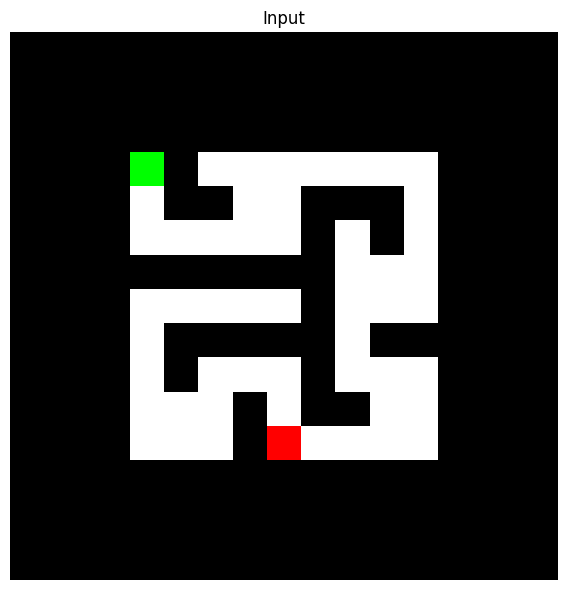

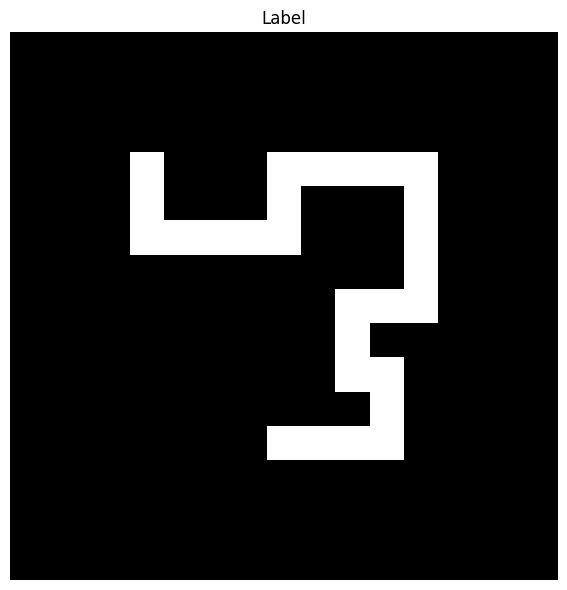

In [22]:
plt.figure(figsize=(6,6))
x_np = np.load('data/maze_data_test_9/inputs.npy')[0]
y_np = np.load('data/maze_data_test_9/solutions.npy')[0]

plt.figure(figsize=(6, 6))
plt.imshow(x_np, origin='upper', aspect='equal')
plt.title('Input')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(y_np, origin='upper', aspect='equal')
plt.title('Label')
plt.axis('off')
plt.tight_layout()
plt.show()

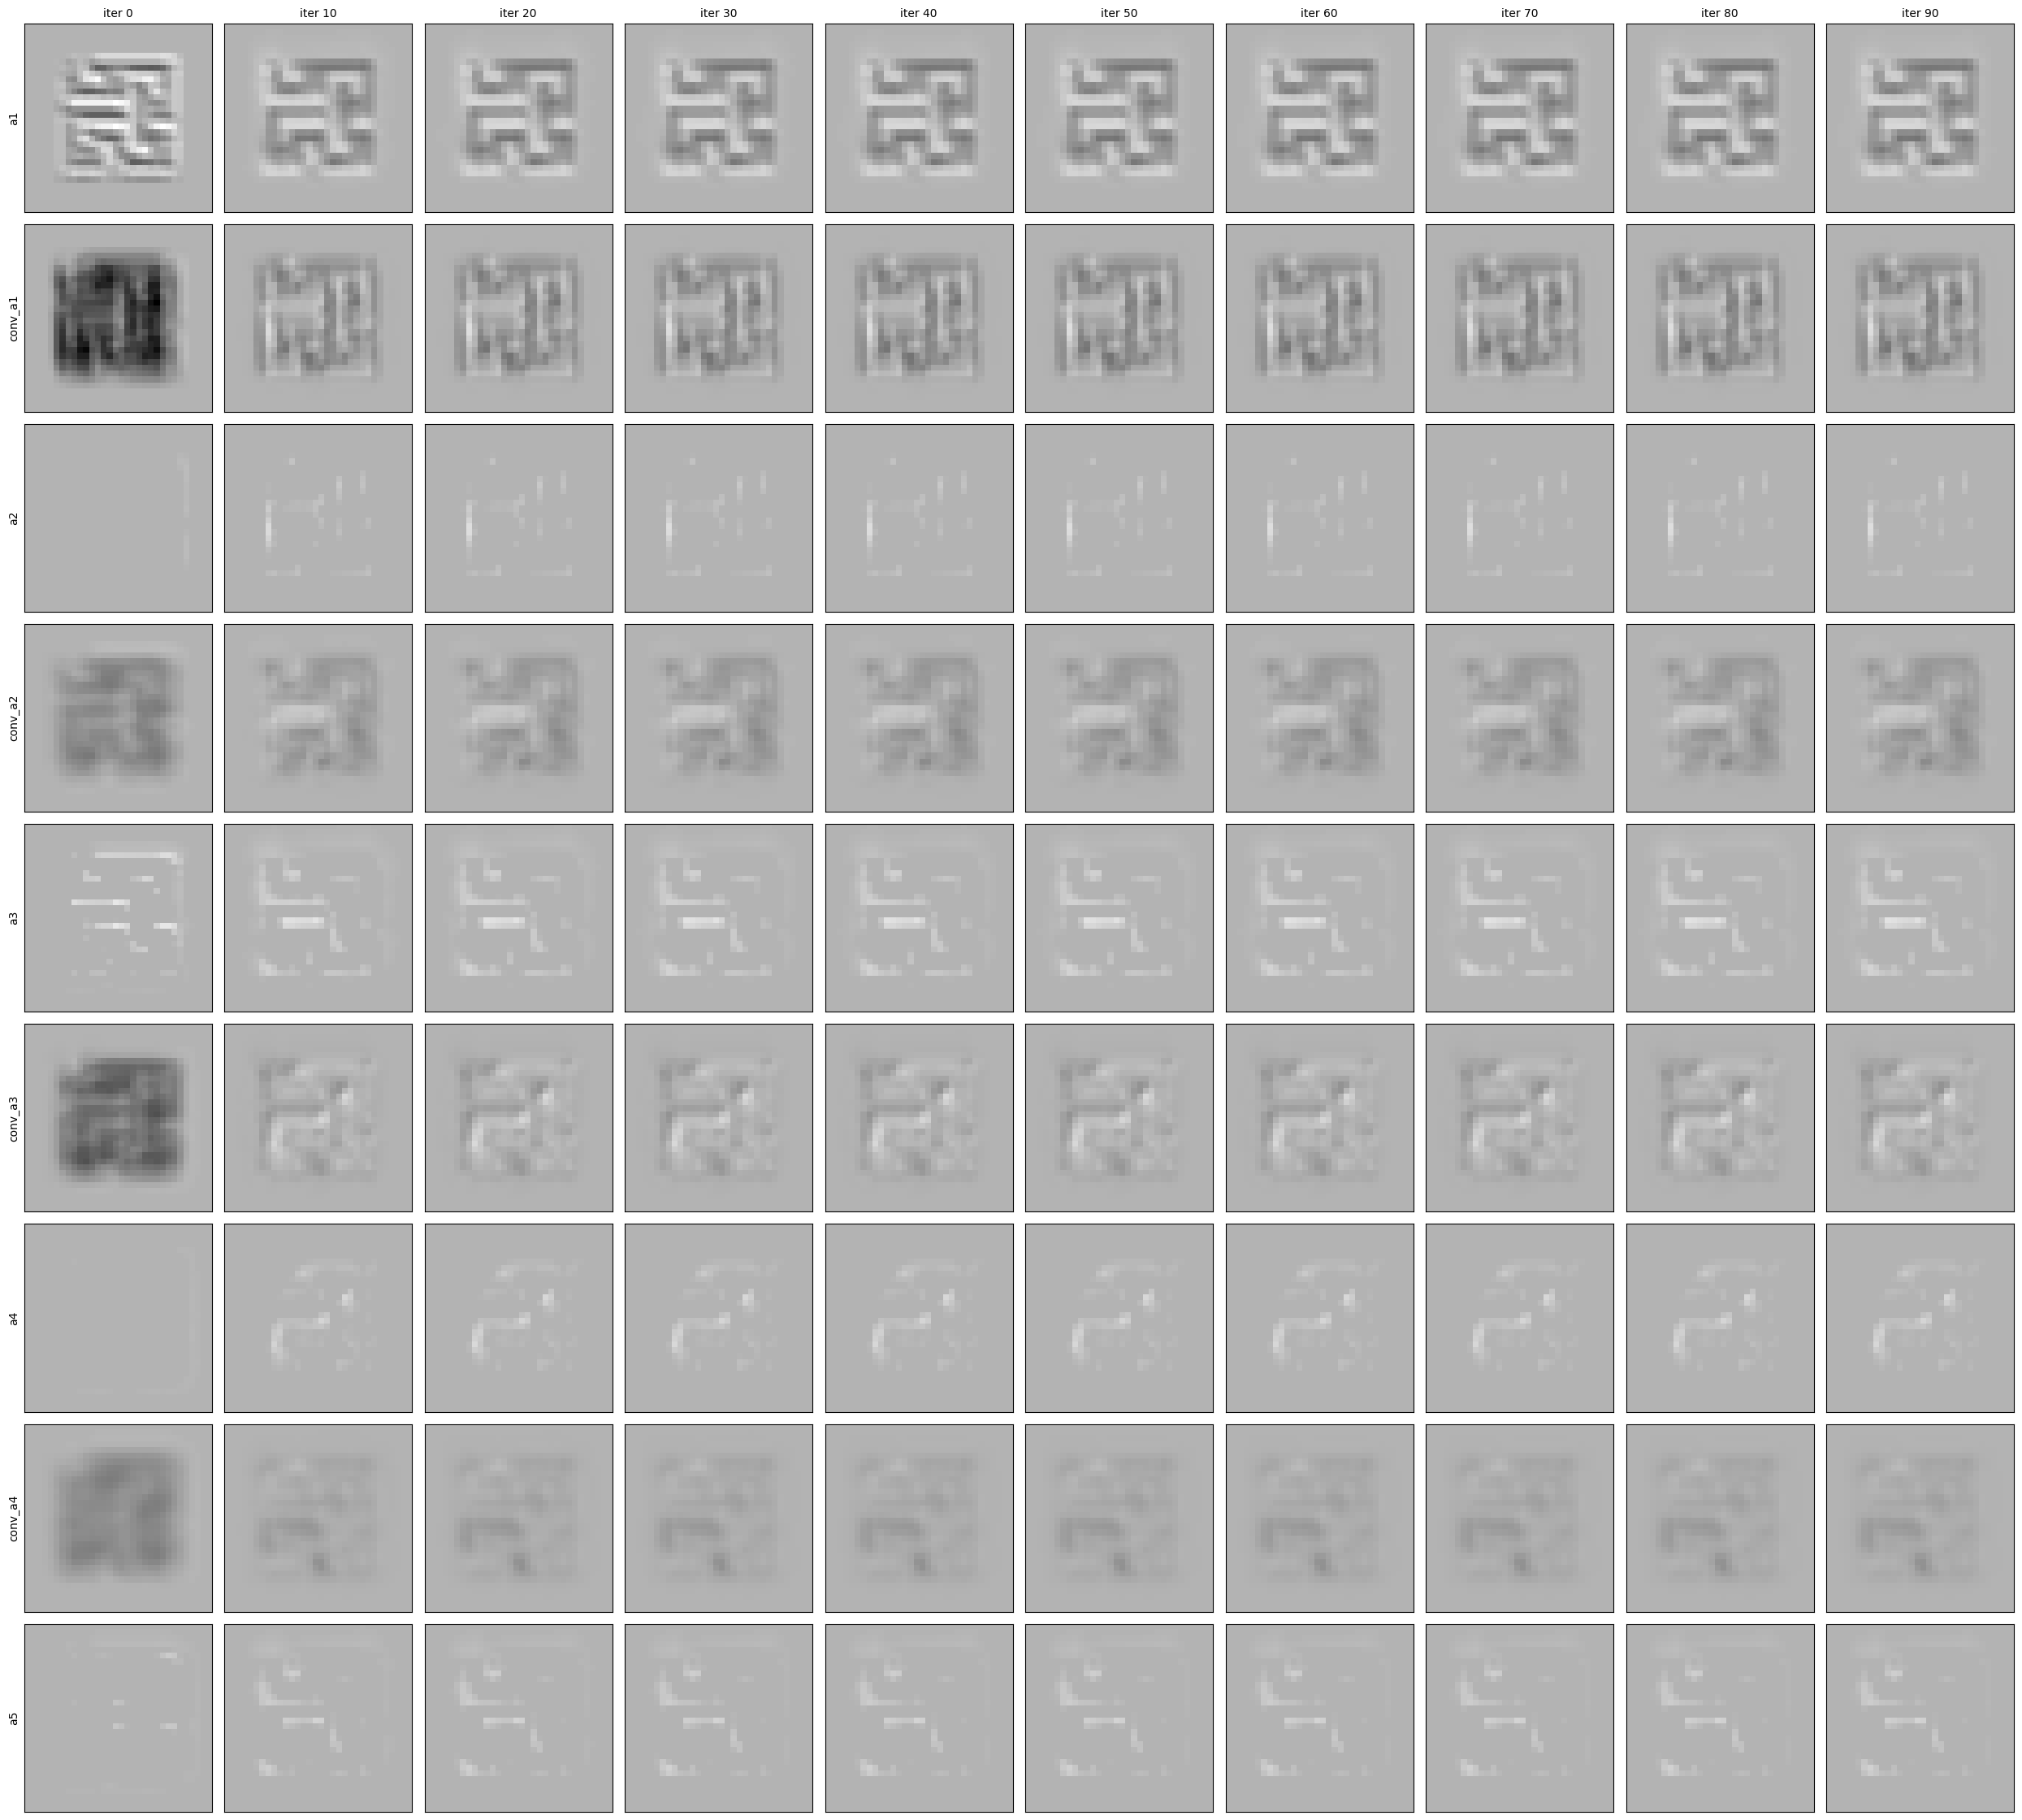

In [7]:
# Now plotting:
# Determine how many snapshots and channels. We'll plot the first channel of each ai (or you can choose)
n_snaps = len(snapshots[0:100:10])
rows = 9  
cols = n_snaps

# choose channel index to visualize (0..C-1). You can pick any, or loop channels.
channel_to_plot = 2

fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
if rows == 1:
    axes = axes[np.newaxis, :]
if cols == 1:
    axes = axes[:, np.newaxis]

# Compute global vmin/vmax across all snapshots and all rows
all_vals = []
row_names = ['a1','conv_a1','a2','conv_a2','a3','conv_a3','a4','conv_a4','a5']
for snap in snapshots:
    for name in row_names:
        all_vals.append(snap[name][channel_to_plot])
all_vals = np.stack(all_vals)  # shape (rows * n_snaps, H, W)
global_vmin = float(all_vals.min())
global_vmax = float(all_vals.max())

# Plot using the same vmin/vmax for every subplot
for col_idx, snap in enumerate(snapshots[0:100:10]):
    for row_idx, name in enumerate(row_names):
        ax = axes[row_idx, col_idx]
        img = snap[name][channel_to_plot]  # (H,W)
        im = ax.imshow(img, cmap='gray', vmin=global_vmin, vmax=global_vmax, origin='upper')
        ax.set_xticks([])
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(f"iter {snap['iter']}", fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
residuals = []
for i in range(25):
    a3 = snapshots[i]['a3'][channel_to_plot]
    conv_a21 = snapshots[i]['conv_a2'][channel_to_plot]
    a1 = snapshots[i]['a1'][channel_to_plot]
    r = a3 - conv_a21 - a1
    residuals.append(r)
residuals = np.stack(residuals, axis=0)

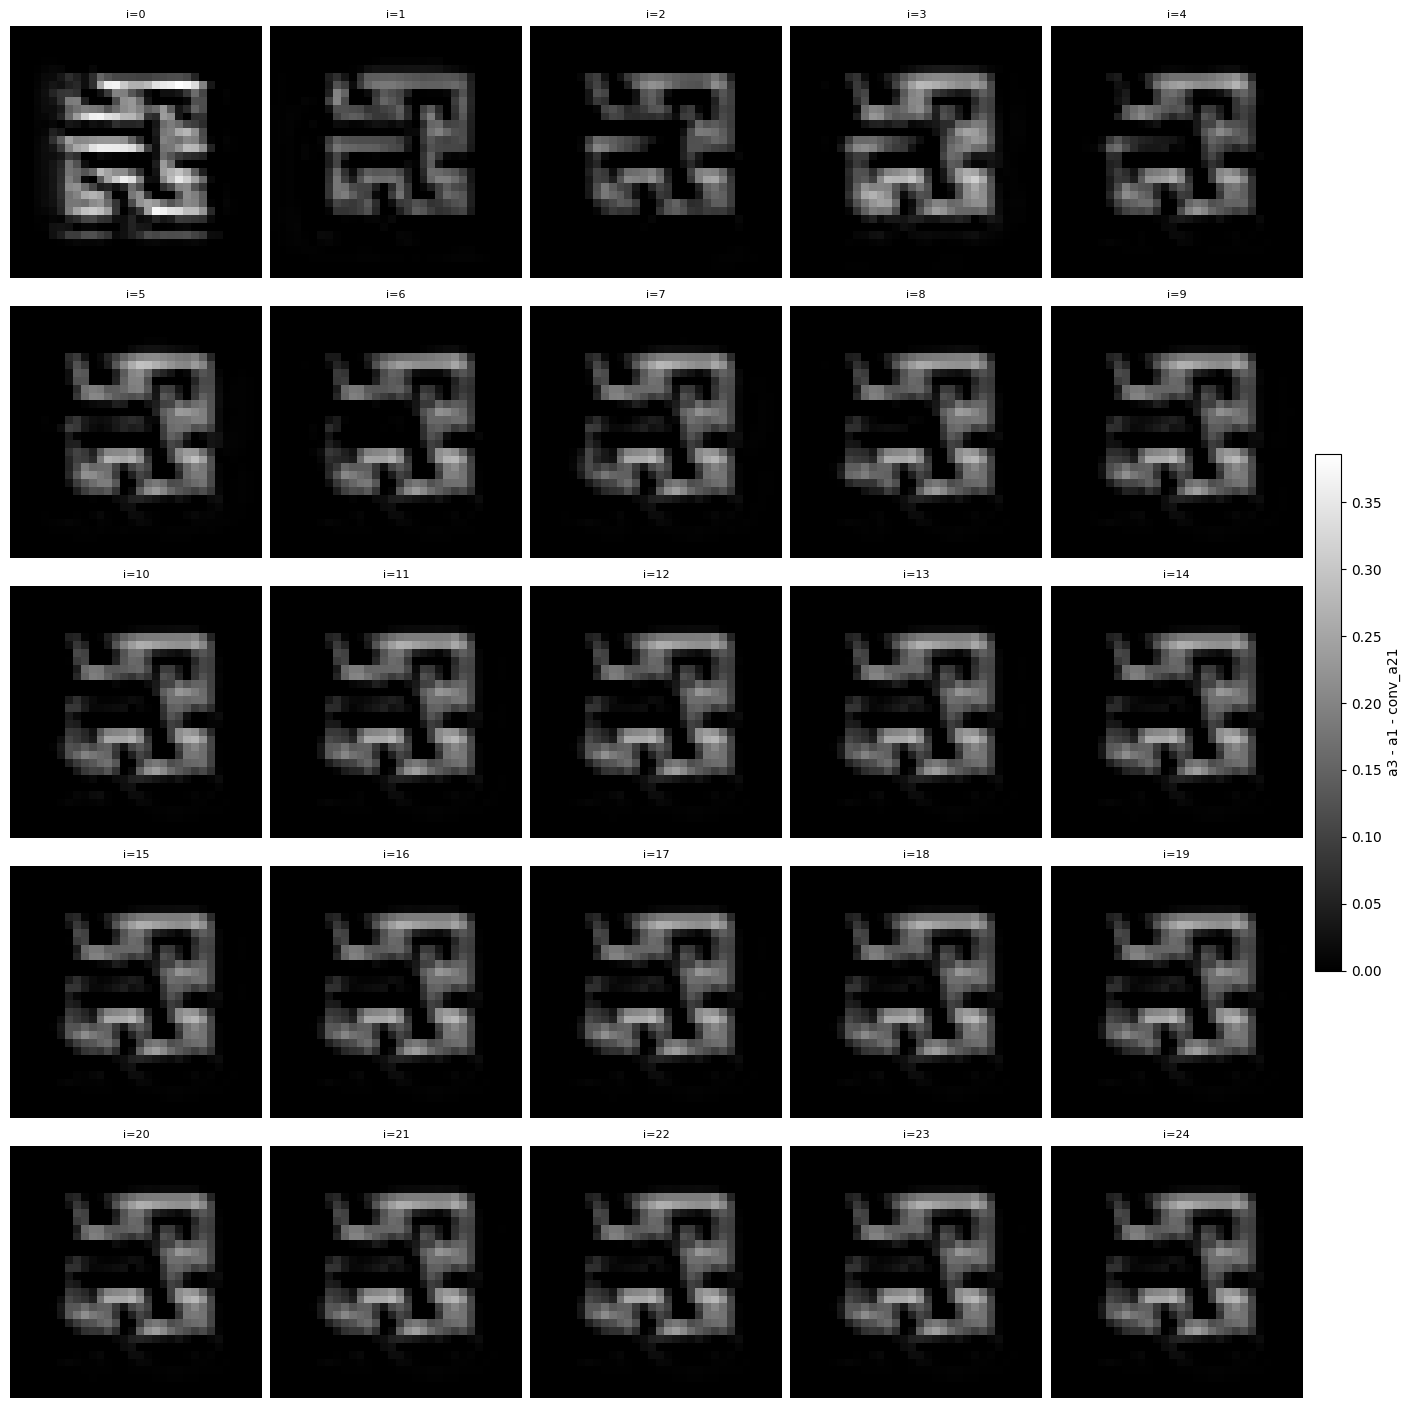

In [13]:
vmin = residuals.min()
vmax = residuals.max()

fig, axes = plt.subplots(5,5, figsize=(14,14), constrained_layout=True)
axes = np.atleast_2d(axes)
k = 0
for r in range(5):
    for c in range(5):
        ax = axes[r, c]
        if k < 25:
            im = ax.imshow(residuals[k], cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
            ax.set_title(f"i={k}", fontsize=8)
            ax.axis('off')
        else:
            ax.axis('off')
        k += 1
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label='a3 - a1 - conv_a21')
plt.show()